<a href="https://colab.research.google.com/github/Ariqq16/PCVK_Ganjil_2026/blob/main/P3/TUGAS-9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

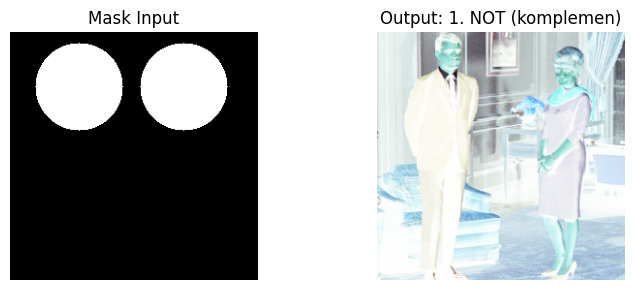

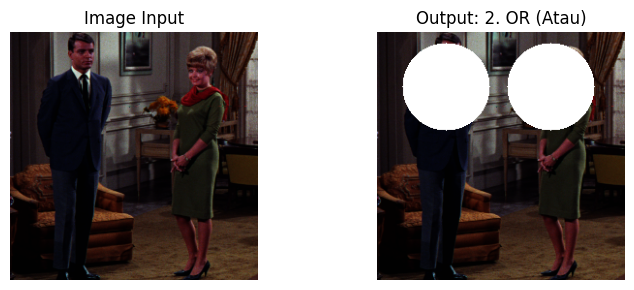

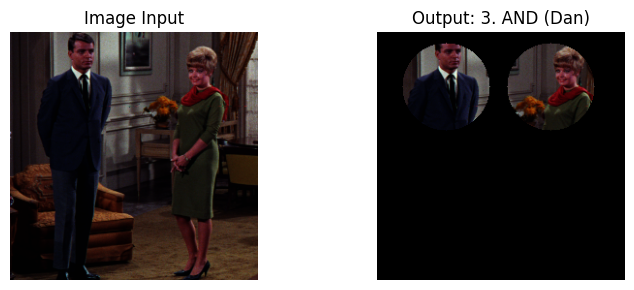

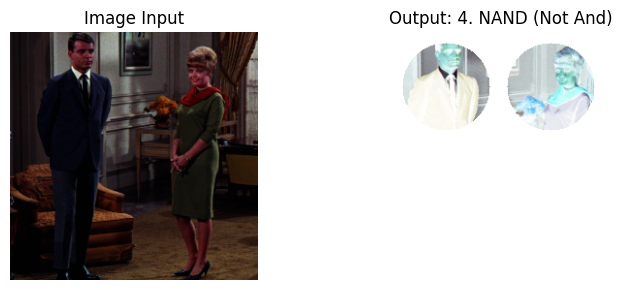

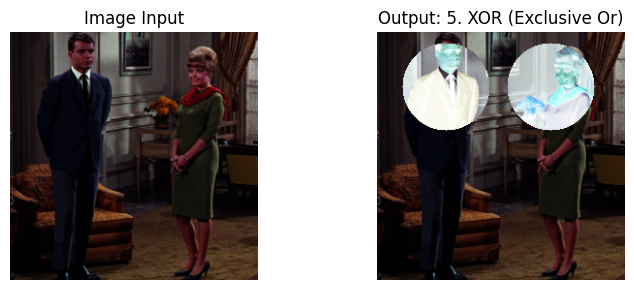

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img_path = '/content/drive/MyDrive/PCVK_2026/couple.tiff'
img = cv.imread(img_path)

if img is None:
    print(f"Error: File tidak ditemukan di {img_path}")
else:
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape

    mask = np.zeros((h, w), dtype=np.uint8)

    cv.circle(mask, (int(w * 0.28), int(h * 0.22)), 45, 255, -1)  # Lingkaran Pria
    cv.circle(mask, (int(w * 0.70), int(h * 0.22)), 45, 255, -1)  # Lingkaran Wanita

    mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2RGB)

    not_result = cv.bitwise_not(img_rgb)
    or_result = cv.bitwise_or(img_rgb, mask_3ch)
    and_result = cv.bitwise_and(img_rgb, mask_3ch)
    nand_result = cv.bitwise_not(and_result)
    xor_result = cv.bitwise_xor(img_rgb, mask_3ch)

    operations = [
        ('1. NOT (komplemen)', img_rgb, not_result),
        ('2. OR (Atau)', img_rgb, or_result),
        ('3. AND (Dan)', img_rgb, and_result),
        ('4. NAND (Not And)', img_rgb, nand_result),
        ('5. XOR (Exclusive Or)', img_rgb, xor_result)
    ]

    for title, inp, out in operations:
        plt.figure(figsize=(8, 3))

        plt.subplot(1, 2, 1)
        plt.imshow(inp if 'NOT' not in title else mask_3ch)
        plt.title('Image Input' if 'NOT' not in title else 'Mask Input')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(out)
        plt.title(f'Output: {title}')
        plt.axis('off')

        plt.tight_layout()
        plt.show()